# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

Usually it is defined as a 2d matrix of costs[i][j] where costs at [i][j] gives us a cost moving from city i to city j. Our goal is to visit every city exactly once and come back to the starting city in the minimum cost (distance). 

reference: https://www.geeksforgeeks.org/dsa/travelling-salesman-problem-using-dynamic-programming/

#### Question 2

1. Our nodes do not create a complete graph as we do not have direct connections to all nodes
2. Nodes can be connected through multiple paths so they are not necessarily singularly connected
3. We do not know the relative distances from each node 

#### Question 3

Because TSP is np-hard we cannot solve it using normal algorithms in sensible time. The CI aproach can give us a really good approximate of the best result in a sensible time in comparison to brute-force approach. We have to give up precision for speed. We use some randomness each iteration using CI to escape local minima to make sure we do not miss a better solution. Also saving only the best routes each iteration gives us already a better start for another iteration (the fittest survive).

### 1.2 Genetic Algorithm

In [2]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        pass

#### Question 4

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 5

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 8

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

In [3]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

TypeError: 'NoneType' object is not subscriptable

<div style="background-color:#f1be3e">

_Put your code extra blocks above (if any) and write your answer here._

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 13

$Δτ^k = Q \cdot \frac{1}{L ^k}$ 

, where $Δτ^k$ is the amount of pheromone left on a path, Q is a constant, $L^k$ is the length of the path

Ants drop pheromone in the maze in order to allow the next ants to follow the shortest path that will have the most pheromone. This is because the shortest paths will be left with the most pheromone, as the amount left is inversely proportional to the length of the path.

#### Question 14

$τ_{ij} = (1 - 	ρ) \cdot τ_{ij}  + \sum_{k=1}^{m} Δτ^k_{ij}$ 

, where $Δτ_{ij}$ is the amount of pheromone currently on path $ij$, $ρ$ is an evaporation constant, $\sum_{k=1}^{m} Δτ^k_{ij}$ is the sum of all the pheromone released on that link by all the ants that passed by it this round 

The pheromone evaporates to make previous decisions influence exploration less. Because of this the colony would not converge to a single path early and should explore many paths because the pheromone left from single bad choices will evaporate.

### 2.3 Implementing the Ant Algorithm

In [167]:
import matplotlib.pyplot as plt
import numpy as np

#Generated by Chat GPT
def draw_maze_matplotlib(walls, ant_pos, start, end):
    plt.clf()

    # transpose: walls[column][row] -> grid[row][column]
    grid = np.array(walls).T

    # show grid (row 0 at top, rows grow downward)
    plt.imshow(grid, origin="upper", interpolation="nearest")

    # scatter uses (x, y) = (column, row)
    plt.scatter([ant_pos.x], [ant_pos.y])
    plt.scatter([start.x], [start.y])
    plt.scatter([end.x], [end.y])

    plt.pause(0.01)

In [178]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        while self.end != self.current_position:
            phn, phs, phe, phw = self.maze.get_surrounding_pheromone(self.current_position)
            total = phn + phs + phw + phe
            n = phn / total
            s = phs / total
            w = phw / total
            e = phe / total
            dir = [0, 1, 2, 3]

            pro = [e, n, w, s]
            choice = random.choices(dir, weights=pro, k=1)[0] #choose a path with weighted probabilities
            print("chances for e: " + str(e))
            print("chances for n: " + str(n))
            print("chances for w: " + str(w))
            print("chances for s: " + str(s))
            if choice == 2:
                self.current_position = self.current_position.subtract_direction(Direction.east)
            elif choice == 3:
                self.current_position = self.current_position.subtract_direction(Direction.north)
            elif choice == 0:
                self.current_position = self.current_position.subtract_direction(Direction.west)
            elif choice == 1:
                self.current_position = self.current_position.subtract_direction(Direction.south)
            else:
                1/0 # else throw an error
            draw_maze_matplotlib(
                self.maze.walls,
                self.current_position,
                self.start,
                self.end
            )
        return route


        


In [175]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        height = len(self.walls[0])
        width = len(self.walls)
        avg_probability = 1/np.sum(self.walls)
        self.pheromones = [None] * (width * height)
        for i in range(height * width):
            col = i // height
            row = i % height
            # first find out positions of the neighbouring tiles, -1 if there are none
            pos_north = i - 1 if row > 0 else -1
            pos_east = i + height if col + 1 < width else -1
            pos_west = i - height if col > 0 else -1
            pos_south = i + 1 if row + 1 < height else -1
            # assign the corresponding probability to them
            north = avg_probability if(pos_north != -1 and self.walls[col][row - 1] == 1) else 0
            east = avg_probability if(pos_east != -1 and self.walls[col + 1][row] == 1) else 0
            west = avg_probability if(pos_west != -1 and self.walls[col - 1][row] == 1) else 0
            south = avg_probability if(pos_south != -1 and self.walls[col][row + 1] == 1) else 0
            self.pheromones[i] = SurroundingPheromone(north, east, south, west)


    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        positions = route.get_route()
        length = route.size()
        current = route.get_start()
        current = current.x + self.width * current.y

        for i in range(length):
            dir = positions[i]
            self.pheromones[current].total_surrounding_pheromone +=  q * 1 / length
            if dir == 0:
                newVal = self.pheromones[current].east + q * 1 / length
                self.pheromones[current].east = newVal
                current = current + 1
                self.pheromones[current].west = newVal
            elif dir == 1:
                newVal = self.pheromones[current].north + q * 1 / length
                self.pheromones[current].north = newVal
                current = current - self.width
                self.pheromones[current].south = newVal
            elif dir == 2:
                newVal = self.pheromones[current].west + q * 1 / length
                self.pheromones[current].west = newVal
                current = current - 1
                self.pheromones[current].east = newVal
            else:
                newVal = self.pheromones[current].south + q * 1 / length
                self.pheromones[current].south = newVal
                current = current + self.width
                self.pheromones[current].north = newVal

            

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for i in range(len(self.walls)):
            # first find out positions of the neighbouring tiles, -1 if there are none
            pos_north = i - self.width if i - self.width >= 0 else -1
            pos_east = i + 1 if (i % self.width) + 1 <= self.width else -1
            pos_west = i - 1 if (i % self.width) - 1 >= 0 else -1
            pos_south = i + self.width if i + self.width <= len(self.walls) else -1
            # assign the corresponding probability to them
            if pos_north != -1: 
                self.pheromones[i].north = (1 - rho) * self.pheromones[i].north 
            if pos_east != -1: 
                self.pheromones[i].east = (1 - rho) *  self.pheromones[i].east
            if pos_west != -1: 
                self.pheromones[i].west = (1 - rho) *  self.pheromones[i].west 
            if pos_south != -1: 
                self.pheromones[i].south = (1 - rho) * self.pheromones[i].south 
            

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        pos = self.pheromones[position.x + position.y * len(self.walls)]
        return pos.north, pos.south, pos.east, pos.west

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified position
    """
    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0
        return self.pheromones[pos.x + self.width * pos.y]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [176]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()
        best_Route = None
        ants = [None] * self.ants_per_gen
        routes = [None] * self.ants_per_gen
     
        for i in range(self.generations):
            for ant in range(self.ants_per_gen):
                ants[ant] = StandardAnt(self.maze, path_specification)
            for ant in range(self.ants_per_gen):
                route = ants[ant].find_route()
                if(best_Route == None or route.shorten_than(best_Route)):
                    best_Route = route
                routes[ant] = route
            self.maze.evaporate()
            self.maze.add_pheromone_routes(routes, self.q)

        return best_Route




Ready reading maze file ./../data/easy_maze.txt
(0, np.float64(0.0048543689320388345), np.float64(0.0048543689320388345), 0)
0, 0
chances for e: 0.5
chances for n: 0.0
chances for w: 0.0
chances for s: 0.5


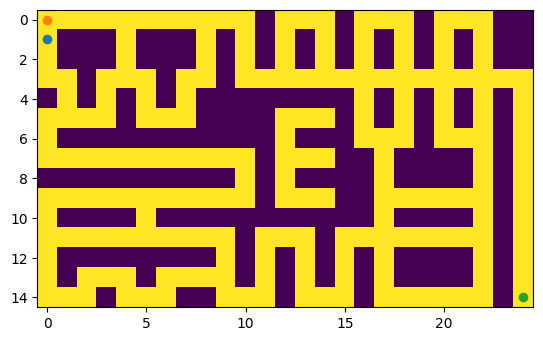

chances for e: 0.0
chances for n: 0.3333333333333333
chances for w: 0.3333333333333333
chances for s: 0.3333333333333333


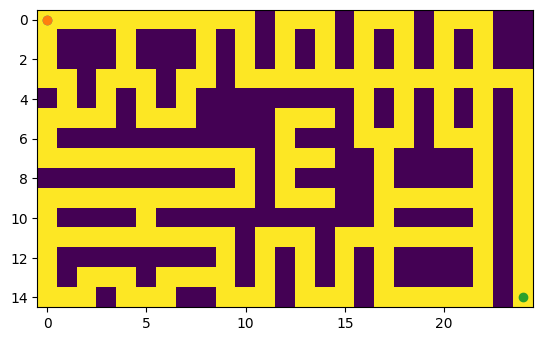

chances for e: 0.5
chances for n: 0.0
chances for w: 0.0
chances for s: 0.5


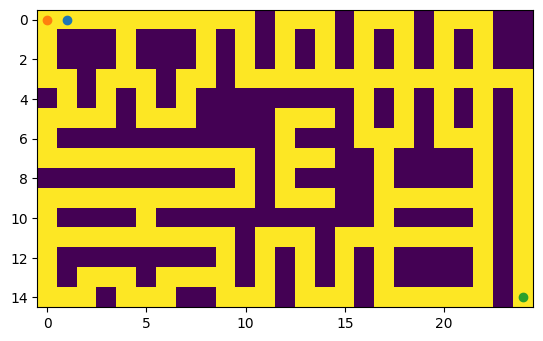

chances for e: 0.0
chances for n: 0.5
chances for w: 0.0
chances for s: 0.5


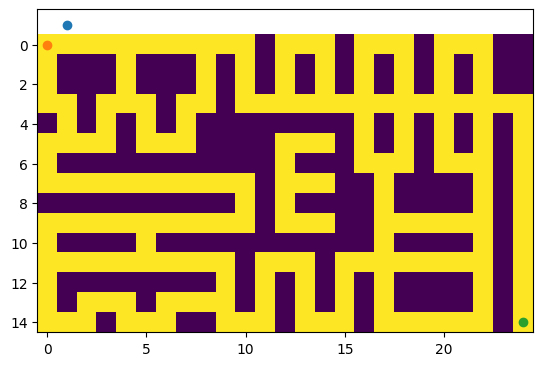

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


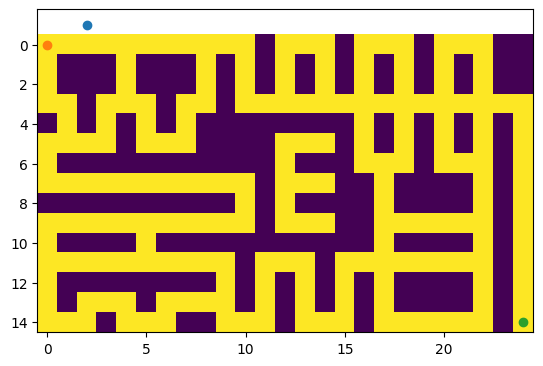

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


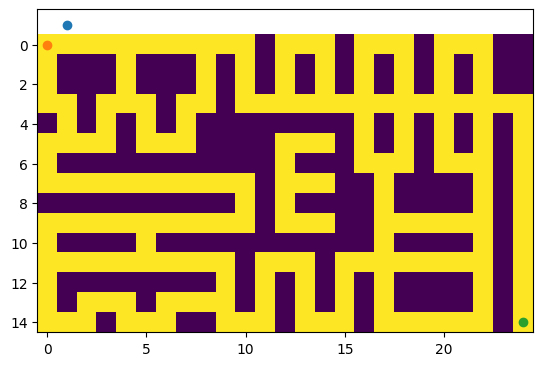

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


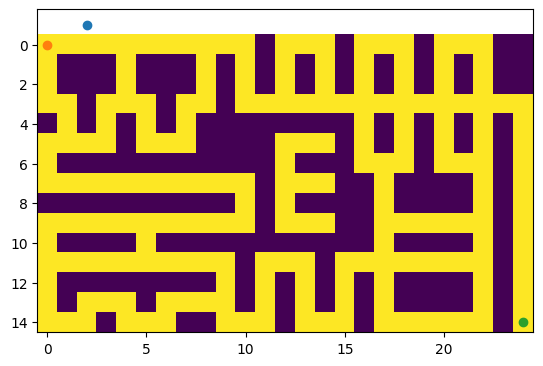

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


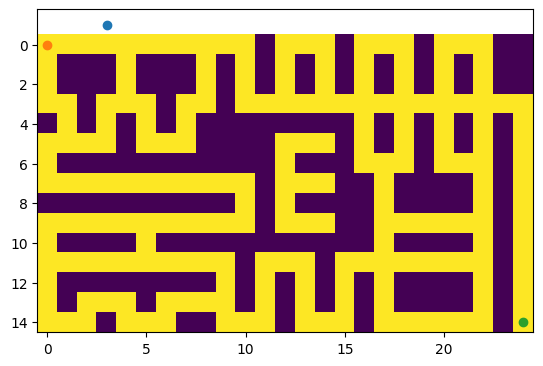

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


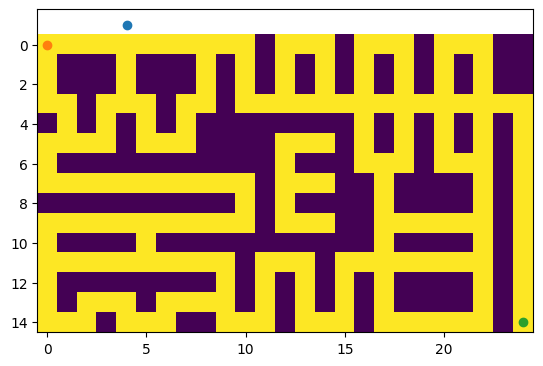

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


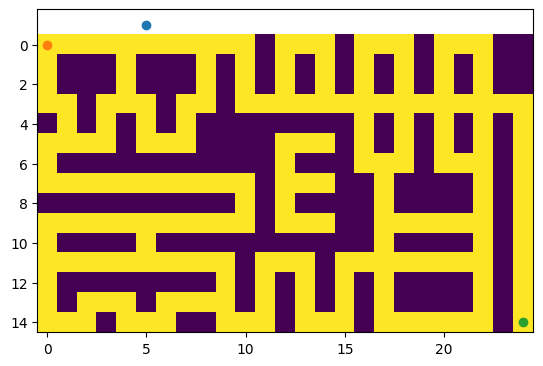

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


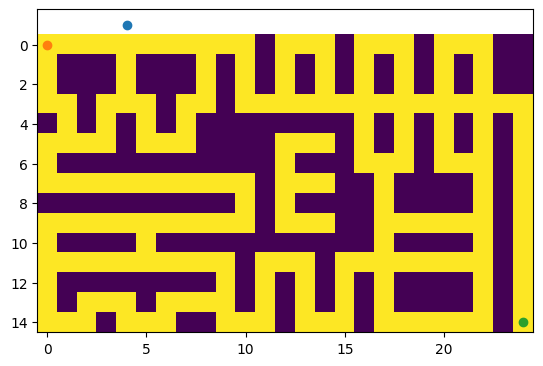

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


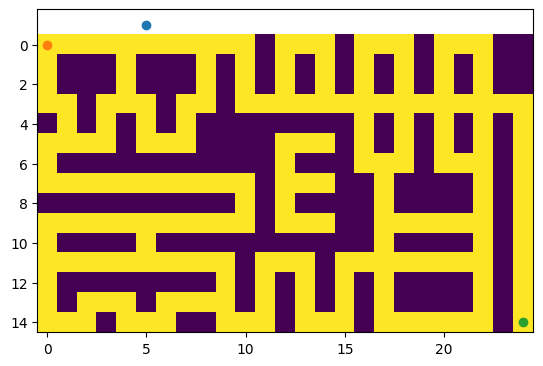

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


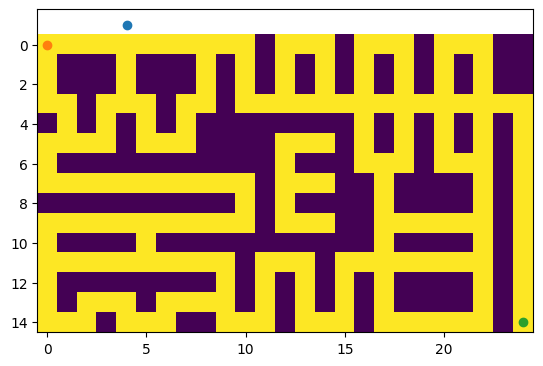

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


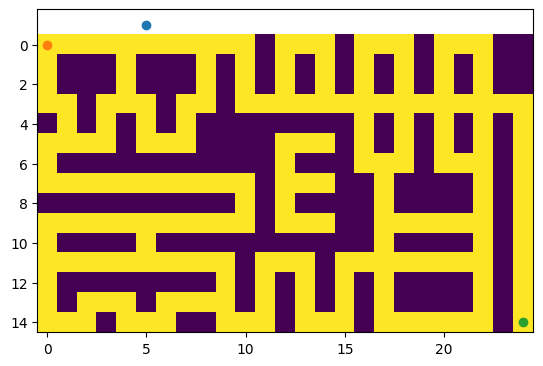

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


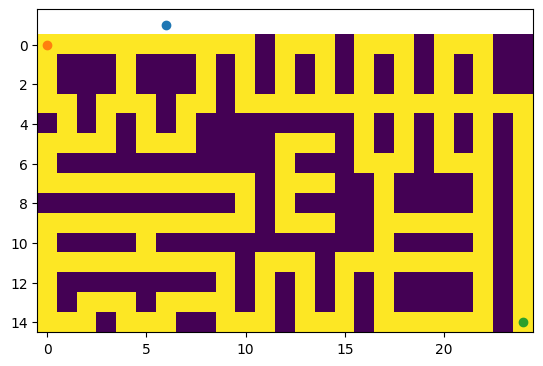

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


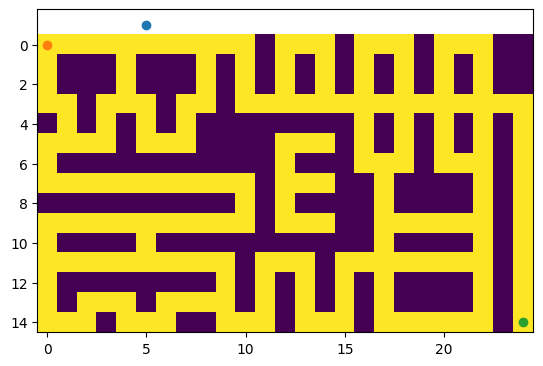

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


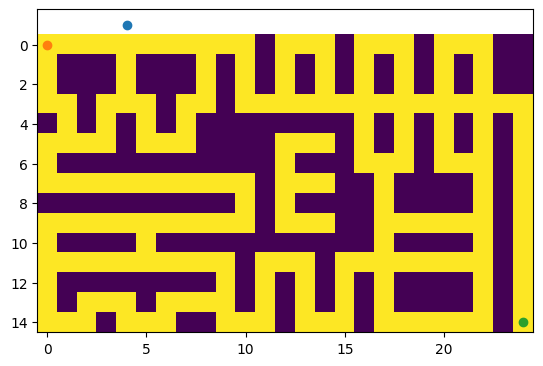

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


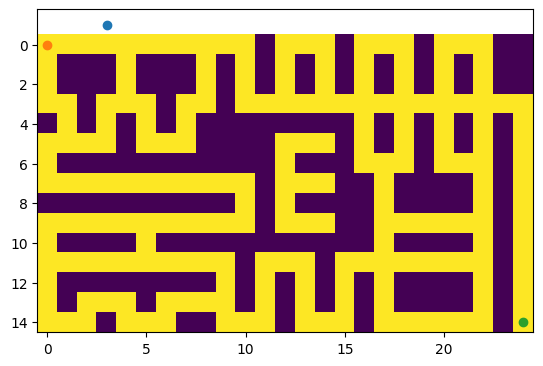

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


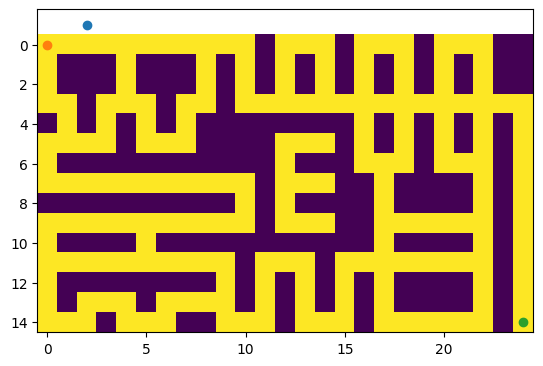

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


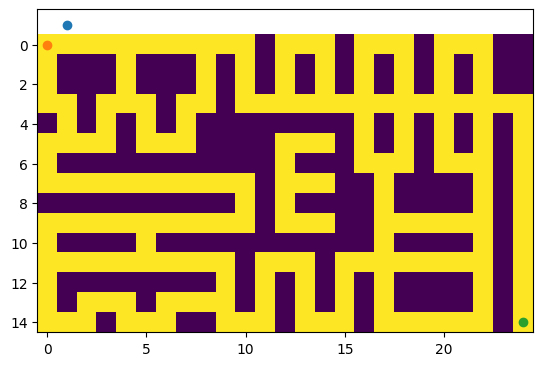

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


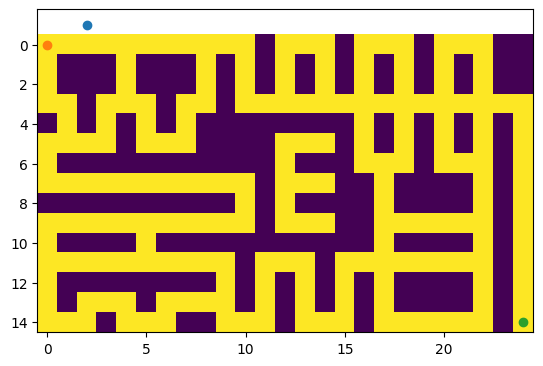

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


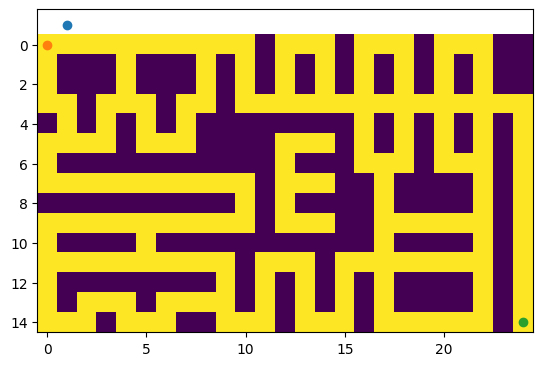

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


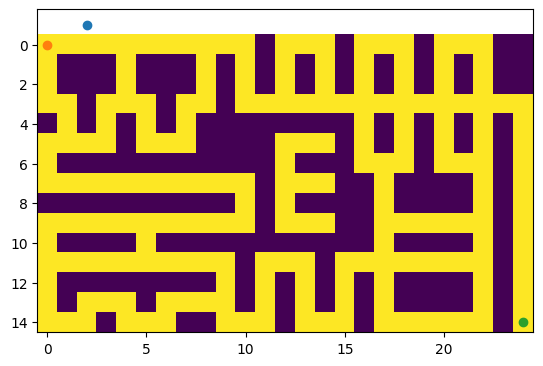

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


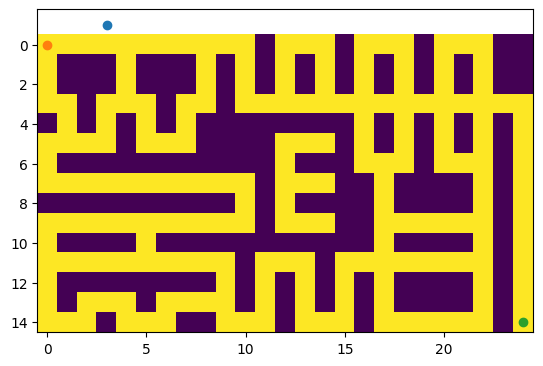

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


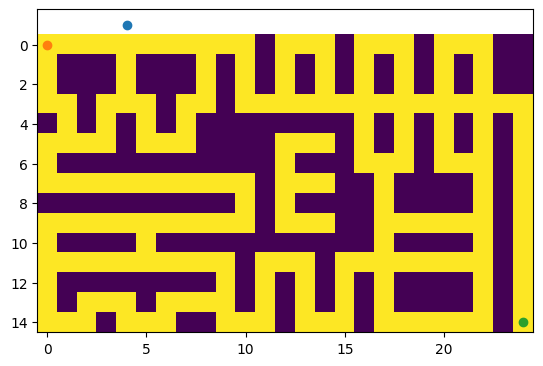

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


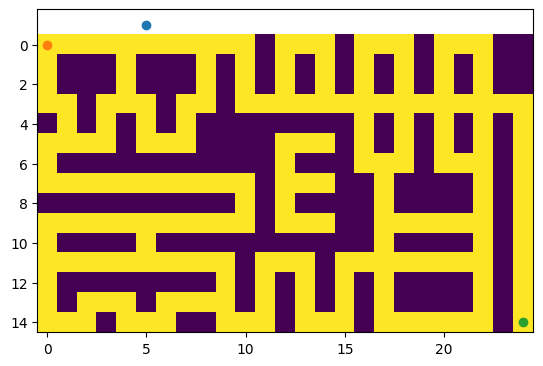

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


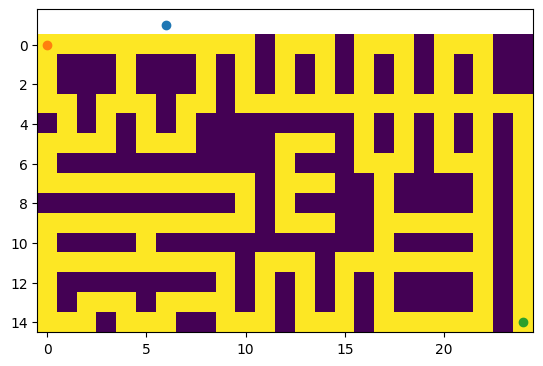

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


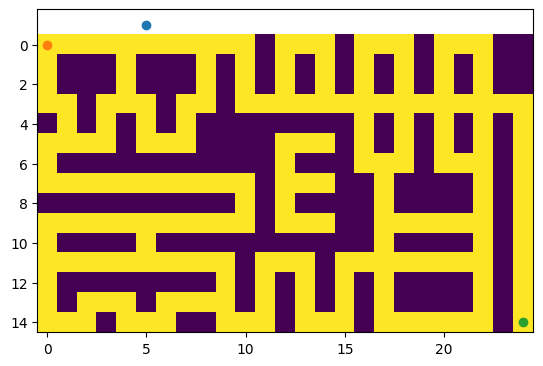

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


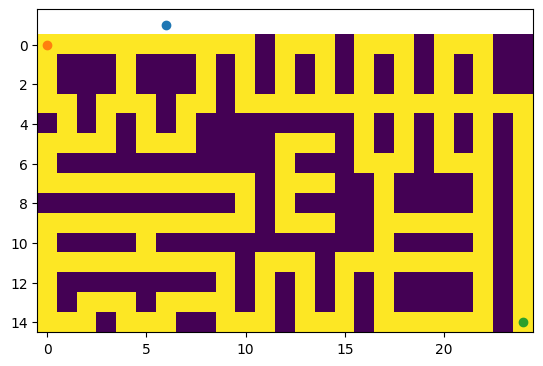

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


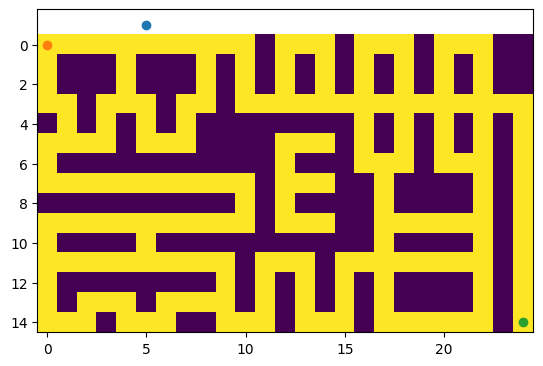

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


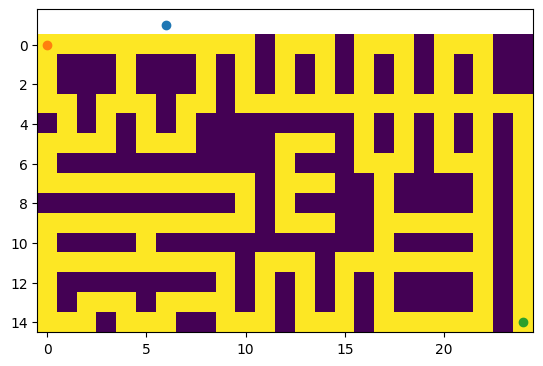

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


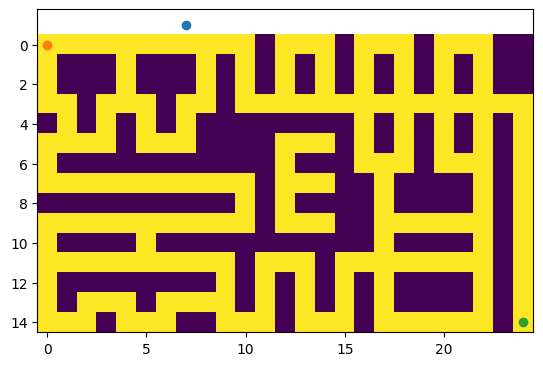

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


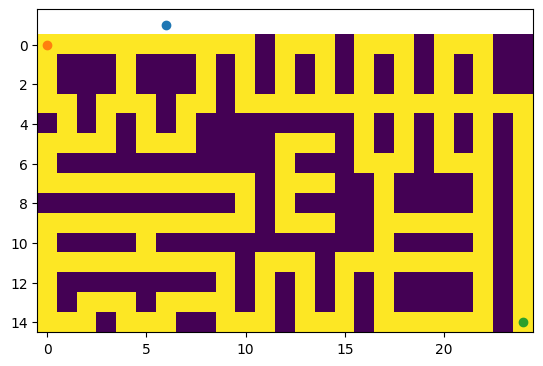

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


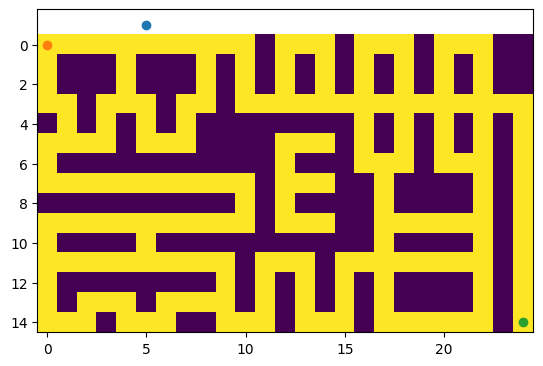

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


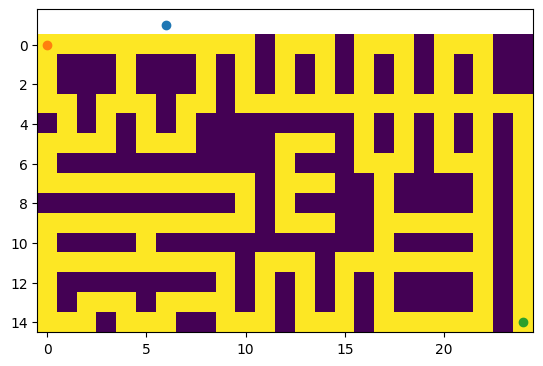

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


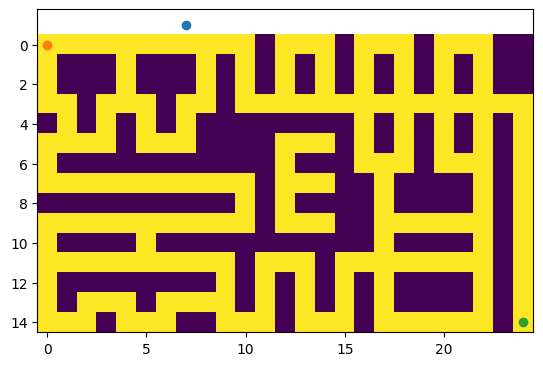

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


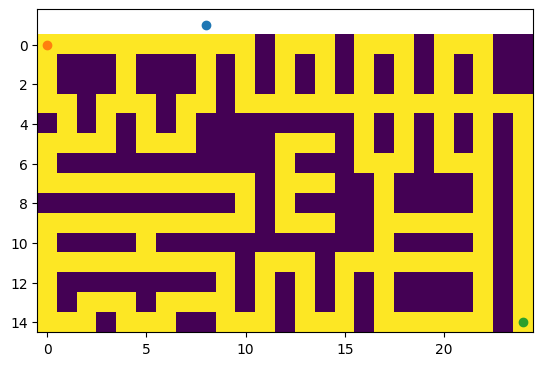

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


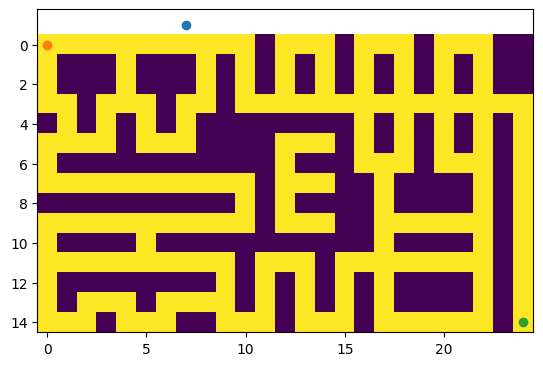

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


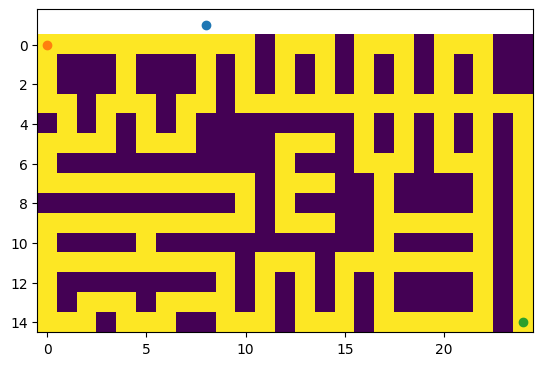

chances for e: 0.5
chances for n: 0.0
chances for w: 0.5
chances for s: 0.0


KeyboardInterrupt: 

In [179]:
# Please keep your parameters for the ACO easily changeable here
gen = 1
no_gen = 1
q = 1600
evap = 0.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)
print(maze.get_surrounding_pheromone(Coordinate(0,0)))
start_time = int(round(time.time() * 1000))
print(spec.get_start())
plt.ion()
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))

shortest_route.write_to_file("./../data/easy_solution.txt")

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [0]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        pass


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

### 2.5 Parameter Optimization

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [0]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**